In [6]:
# dataset:-https://drive.google.com/file/d/1CnE8T3t7CsZi9HXe5hn_tTT_mrKvQJnp/view?usp=sharing

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv('/content/census-income_.csv')

In [9]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [10]:
df.shape

(32561, 15)

In [12]:
df.columns = df.columns.str.strip()
df[(df['workclass']=='?' ) | (df['occupation']=='?') | (df['native-country']=='?')]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual Income


In [13]:
df['workclass']=df['workclass'].replace("?",np.nan)
df['occupation']=df['occupation'].replace("?",np.nan)
df['native-country']=df['native-country'].replace("?",np.nan)

In [14]:
df[(df['workclass']=='?' ) | (df['occupation']=='?') | (df['native-country']=='?')]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual Income


In [15]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [16]:
df['workclass']=df['workclass'].fillna(df['workclass'].mode()[0])

In [17]:
df['occupation']=df['occupation'].fillna(df['occupation'].mode()[0])

In [18]:
df['native-country']=df['native-country'].fillna(df['native-country'].mode()[0])

In [19]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
df.duplicated().sum()

np.int64(24)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

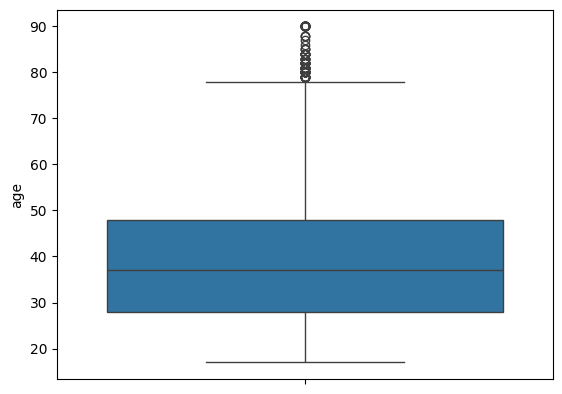

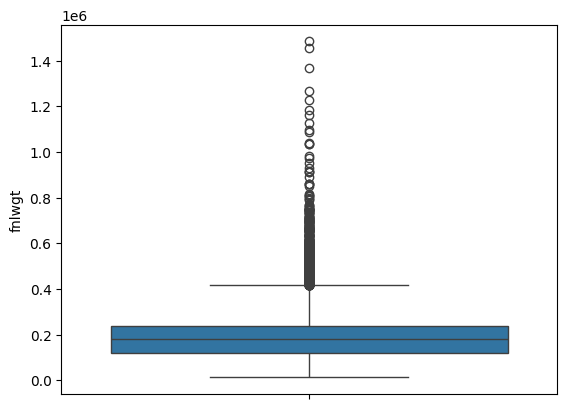

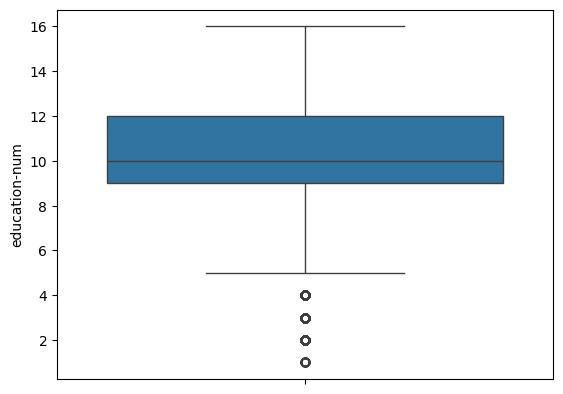

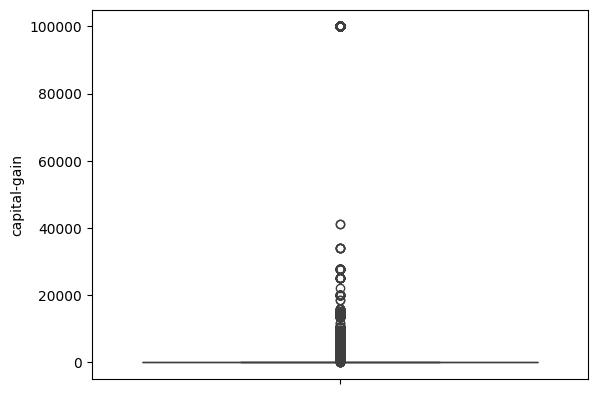

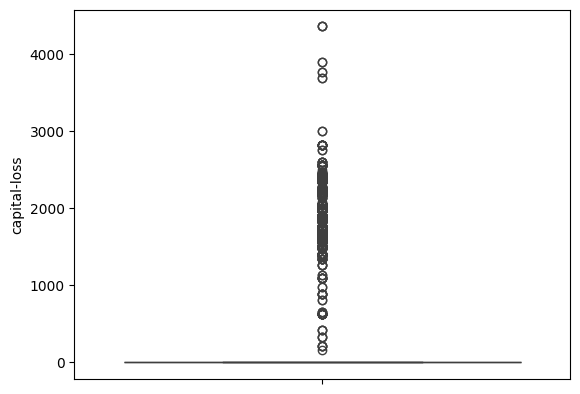

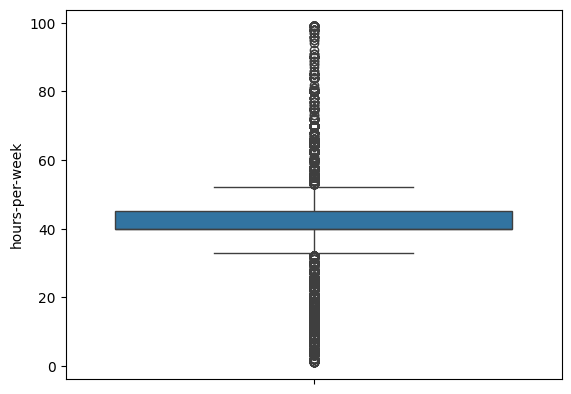

In [23]:
for col in df.columns:
  if(df[col].dtype!='object'):
    sns.boxplot(df[col])
    plt.show()

In [24]:
out_list=['age','education-num','fnlwgt','hours-per-week']
for col in out_list:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  IQR=Q3-Q1

  LB=Q1-1.5*(IQR)
  UB=Q3+1.5*(IQR)

  df=df[(df[col]>=LB) & (df[col]<=UB)]

In [25]:
df.shape

(21926, 15)

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
LE=LabelEncoder()

In [28]:
for col in df.columns:
  if(df[col].dtype=='object'):
    df[col]=LE.fit_transform(df[col])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21926 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             21926 non-null  int64
 1   workclass       21926 non-null  int64
 2   fnlwgt          21926 non-null  int64
 3   education       21926 non-null  int64
 4   education-num   21926 non-null  int64
 5   marital-status  21926 non-null  int64
 6   occupation      21926 non-null  int64
 7   relationship    21926 non-null  int64
 8   race            21926 non-null  int64
 9   sex             21926 non-null  int64
 10  capital-gain    21926 non-null  int64
 11  capital-loss    21926 non-null  int64
 12  hours-per-week  21926 non-null  int64
 13  native-country  21926 non-null  int64
 14  annual Income   21926 non-null  int64
dtypes: int64(15)
memory usage: 2.7 MB


In [31]:
x=df.drop('annual Income',axis=1)
y=df['annual Income']

In [32]:
x

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,7,77516,6,13,4,1,1,4,1,2174,0,40,39
2,38,4,215646,8,9,0,6,1,4,1,0,0,40,39
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39
4,28,4,338409,6,13,2,10,5,2,0,0,0,40,5
5,37,4,284582,9,14,2,4,5,4,0,0,0,40,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,22,4,310152,11,10,4,11,1,4,1,0,0,40,39
32556,27,4,257302,4,12,2,13,5,4,0,0,0,38,39
32557,40,4,154374,8,9,2,7,0,4,1,0,0,40,39
32558,58,4,151910,8,9,6,1,4,4,0,0,0,40,39


In [33]:
y

,annual Income
0,0
2,0
3,0
4,0
5,0
...,...
32555,0
32556,0
32557,1
32558,0


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
model_lr=LogisticRegression()

In [38]:
model_lr.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [39]:
y_pred=model_lr.predict(x_test)

In [40]:
from sklearn.metrics import *

In [41]:
accuracy_score(y_pred,y_test)*100

79.91336069311446

In [42]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
model_dt=DecisionTreeClassifier()

In [45]:
model_dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [46]:
y_pred_dt=model_dt.predict(x_test)

In [47]:
accuracy_score(y_pred_dt,y_test)*100

78.88736890104879

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
model_rf=RandomForestClassifier()

In [50]:
model_rf.fit(x_train,y_train)

RandomForestClassifier()

In [51]:
y_pred_rf=model_rf.predict(x_test)

In [52]:
accuracy_score(y_test,y_pred_rf)*100

84.33652530779754